# Olist - Late Delivery Prediction: Model Benchmark

**Goal:** benchmark models that predict, at purchase time, whether an order will be delivered after the customer-facing estimated delivery date (`late = 1`).

Exploratory feature diagnostics live in `02_delivery_feature_exploration.ipynb`. This notebook starts from the curated, leakage-safe production feature set in `src.features` and focuses on model training, validation, comparison, and production smoke tests.

Benchmark candidates:

1. **Weighted Logistic Regression** - strong, interpretable baseline with `class_weight="balanced"`.
2. **XGBoost** - boosted trees with `scale_pos_weight` set to the train-fold negative-to-positive ratio for the late-delivery class imbalance; this is the production model promoted in `src.model`.
3. **LightGBM** - boosted trees with class weights.
4. **HistGradientBoostingClassifier** - pure scikit-learn boosted-tree fallback, retained as a benchmark comparison point.

Primary comparison metrics are **PR AUC** and **F1** because late deliveries are the minority class. Calibration curves and Brier score are included because weighted classifiers can distort probability estimates.

### Why these models?

**Why weighted logistic regression?**

- **Interpretable baseline.** Logistic regression gives signed coefficients and odds ratios, so it is a readable benchmark for the more complex models.
- **Why weighted (`class_weight="balanced"`)?** Late deliveries are the minority class. Weighting the rare class keeps the model from optimizing mostly for on-time orders.
- **A good first approach.** It is a sanity check on the feature pipeline before introducing higher-variance models.

**Why gradient boosted trees (XGBoost, LightGBM, and HistGradientBoosting)?**

- **Capture non-linearities and interactions automatically.** Delivery lateness is unlikely to be a clean linear function of the inputs.
- **Handle class imbalance natively.** XGBoost uses the train-fold negative-to-positive ratio, while LightGBM and HistGradientBoosting use `class_weight="balanced"`.
- **Strong tabular candidates.** Benchmarking multiple implementations checks whether any lift is robust to the specific library.

**The trade-off being tested:** weighted logistic regression prioritizes interpretability, while boosted trees prioritize ranking power and interactions. XGBoost is the shipped production model because it slightly leads the latest benchmark table across validation F1, PR AUC, thresholded F1, and Brier score. HistGradientBoosting remains a simpler pure scikit-learn fallback.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_delivery_dataset
from src.features import CATEGORICAL_FEATURES, FEATURE_COLUMNS, NUMERIC_FEATURES, TARGET_COLUMN, TIME_COLUMN

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

DATA_DIR = PROJECT_ROOT / "data"
RANDOM_STATE = 42  # fixed seed for reproducible benchmarks

missing_optional = []
if XGBClassifier is None:
    missing_optional.append("xgboost")
if LGBMClassifier is None:
    missing_optional.append("lightgbm")

if missing_optional:
    print("Optional benchmark packages missing:", ", ".join(missing_optional))
    print("Install with: pip install xgboost lightgbm")

## Load Leakage-Safe Modeling Table

The separate feature exploration notebook documents the broader candidate set. The models below use the curated, leakage-safe subset defined in `src.features`.

The feature table comes from `src.features.build_delivery_dataset` through `load_delivery_dataset`. It keeps only features known at checkout and excludes post-purchase timestamps such as carrier delivery and customer delivery dates.


In [2]:
df = load_delivery_dataset(DATA_DIR)  # src/data_loader.py::load_delivery_dataset

summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "late_rate": df[TARGET_COLUMN].mean(),
        "on_time_to_late_ratio": (1 - df[TARGET_COLUMN].mean()) / df[TARGET_COLUMN].mean(),
        "start_date": df[TIME_COLUMN].min().date(),
        "end_date": df[TIME_COLUMN].max().date(),
    }
)
summary

rows                          96470
columns                          26
late_rate                     0.081
on_time_to_late_ratio        11.327
start_date               2016-09-15
end_date                 2018-08-29
dtype: object

In [3]:
df[[TIME_COLUMN, TARGET_COLUMN, *FEATURE_COLUMNS]].describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96470,2018-01-01 23:17:43.624412,2016-09-15 12:16:38,2017-09-14 08:56:46.500000,2018-01-20 19:34:43.500000,2018-05-05 18:29:50.250000,2018-08-29 15:00:37,NaN
late,"96,470.000",0.081,0.000,0.000,0.000,0.000,1.000,0.273
estimated_delivery_days,"96,470.000",23.736,2.008,18.330,23.231,28.408,155.135,8.761
shipping_limit_days,"96,470.000",6.575,2.004,5.006,6.012,7.136,"1,052.005",4.661
purchase_month,"96,470.000",6.031,1.000,3.000,6.000,8.000,12.000,3.228
purchase_dayofweek,"96,470.000",2.756,0.000,1.000,3.000,4.000,6.000,1.967
purchase_hour,"96,470.000",14.773,0.000,11.000,15.000,19.000,23.000,5.328
n_items,"96,470.000",1.142,1.000,1.000,1.000,1.000,21.000,0.539
n_distinct_products,"96,470.000",1.039,1.000,1.000,1.000,1.000,8.000,0.228
n_sellers,"96,470.000",1.014,1.000,1.000,1.000,1.000,5.000,0.124


## Chronological Train / Validation / Test Split

The split follows the production shape: train on older orders and evaluate on future orders. The validation slice is used only to choose the F1 operating threshold; final PR AUC, F1, Brier score, and calibration curves are reported on the most recent test slice.

In [4]:
def chronological_three_way_split(
    dataset: pd.DataFrame,
    valid_frac: float = 0.2,
    test_frac: float = 0.2,
    time_column: str = TIME_COLUMN,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ordered = dataset.sort_values(time_column).reset_index(drop=True)
    test_start = int(len(ordered) * (1 - test_frac))
    valid_start = int(test_start * (1 - valid_frac))
    return (
        ordered.iloc[:valid_start].copy(),
        ordered.iloc[valid_start:test_start].copy(),
        ordered.iloc[test_start:].copy(),
    )


train, valid, test = chronological_three_way_split(df)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train), len(valid), len(test)],
        "late_rate": [train[TARGET_COLUMN].mean(), valid[TARGET_COLUMN].mean(), test[TARGET_COLUMN].mean()],
        "start": [train[TIME_COLUMN].min(), valid[TIME_COLUMN].min(), test[TIME_COLUMN].min()],
        "end": [train[TIME_COLUMN].max(), valid[TIME_COLUMN].max(), test[TIME_COLUMN].max()],
    }
)
split_summary

,split,rows,late_rate,start,end
0,train,61740,0.090,2016-09-15 12:16:38,2018-03-20 09:15:24
1,validation,15436,0.081,2018-03-20 09:16:16,2018-05-26 18:16:57
2,test,19294,0.053,2018-05-26 18:18:03,2018-08-29 15:00:37


## Logistic Regression Categorical Guardrail

Weighted logistic regression stays interpretable only if its one-hot encoded categorical matrix remains reasonably small. This guardrail is applied only to that baseline: if the categorical feature set gets too wide, columns are ranked by Cramer's V against the target and lower-association columns are dropped until the encoded width fits the configured budget.

Tree-based benchmark models keep the full configured categorical feature set from `src.features`.


In [5]:
MAX_LOGIT_DUMMY_COLUMNS = 80
MIN_CATEGORICAL_CRAMERS_V = 0.02
ONEHOT_MIN_FREQUENCY = 20  # shared with the OneHotEncoder in make_preprocessor


def encoded_width(feature: pd.Series, min_frequency: int = ONEHOT_MIN_FREQUENCY) -> int:
    """Number of one-hot columns ``OneHotEncoder(min_frequency=...)`` actually emits:
    one per level seen at least ``min_frequency`` times, plus one shared column if any
    rare levels get collapsed. This is the real design-matrix width, which is <= nunique."""
    counts = feature.value_counts(dropna=True)
    frequent = int((counts >= min_frequency).sum())
    has_infrequent = bool((counts < min_frequency).any())
    return frequent + int(has_infrequent)


def cramers_v(feature: pd.Series, target: pd.Series) -> float:
    table = pd.crosstab(feature.fillna("__missing__"), target)
    if min(table.shape) < 2:
        return 0.0

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    rows, cols = table.shape
    denom = max(1, min(rows - 1, cols - 1))
    return float(np.sqrt(phi2 / denom))


def select_logistic_categoricals(
    dataset: pd.DataFrame,
    categorical_features: list[str],
    target: str = TARGET_COLUMN,
    max_dummy_columns: int = MAX_LOGIT_DUMMY_COLUMNS,
    min_cramers_v: float = MIN_CATEGORICAL_CRAMERS_V,
    min_frequency: int = ONEHOT_MIN_FREQUENCY,
) -> tuple[list[str], pd.DataFrame]:
    profile = pd.DataFrame(
        [
            {
                "feature": feature,
                "n_unique_train": dataset[feature].nunique(dropna=False),
                "encoded_width_train": encoded_width(dataset[feature], min_frequency),
                "cramers_v_to_target": cramers_v(dataset[feature], dataset[target]),
            }
            for feature in categorical_features
        ]
    ).sort_values("cramers_v_to_target", ascending=False)

    # Budget against the width the encoder actually emits (min_frequency collapses rare
    # levels), not raw cardinality. n_unique_train is kept only as an informational column.
    total_width = int(profile["encoded_width_train"].sum())
    if total_width <= max_dummy_columns:
        return categorical_features, profile.assign(selected=True, reason="within one-hot budget")

    selected: list[str] = []
    used_width = 0
    reasons: dict[str, str] = {}
    for row in profile.itertuples(index=False):
        enough_signal = row.cramers_v_to_target >= min_cramers_v
        fits_budget = used_width + row.encoded_width_train <= max_dummy_columns
        if enough_signal and (fits_budget or not selected):
            selected.append(row.feature)
            used_width += int(row.encoded_width_train)
            reasons[row.feature] = "kept: stronger target association"
        else:
            reasons[row.feature] = "dropped: lower association or budget pressure"

    return selected, profile.assign(
        selected=profile["feature"].isin(selected),
        reason=profile["feature"].map(reasons),
    )


logistic_categorical_features, categorical_profile = select_logistic_categoricals(train, CATEGORICAL_FEATURES)
logistic_feature_columns = NUMERIC_FEATURES + logistic_categorical_features

print("Logistic categorical features:", logistic_categorical_features)
categorical_profile

Logistic categorical features: ['customer_state', 'seller_state', 'payment_type']


,feature,n_unique_train,encoded_width_train,cramers_v_to_target,selected,reason
0,customer_state,27,27,0.156,True,within one-hot budget
1,seller_state,22,17,0.055,True,within one-hot budget
2,payment_type,5,4,0.017,True,within one-hot budget


## Model Definitions

All models use the same leakage-safe feature table. The logistic model scales numeric features and one-hot encodes only the categorical features selected by the logistic guardrail above. The tree models use the full configured categorical feature set (`CATEGORICAL_FEATURES`) and do not need numeric scaling.

`scale_pos_weight` for XGBoost is set to the negative-to-positive ratio measured on the chronological train fold, so the class weighting always matches the data the model is actually fit on. That ratio is computed and printed below.

The **XGBoost** model uses the same estimator family and hyperparameters promoted to `src.model.build_model_pipeline` (`n_estimators=500`, `learning_rate=0.05`, `max_depth=4`, `subsample=0.8`, `colsample_bytree=0.8`, dynamic `scale_pos_weight`). The **HistGradientBoosting** row remains as a pure scikit-learn fallback comparison.


In [6]:
def make_preprocessor(categorical_features: list[str], *, scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    numeric = Pipeline(steps=numeric_steps)
    categorical = Pipeline(
        steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=ONEHOT_MIN_FREQUENCY, sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric, NUMERIC_FEATURES),
            ("cat", categorical, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


observed_scale_pos_weight = (train[TARGET_COLUMN] == 0).sum() / (train[TARGET_COLUMN] == 1).sum()
print(f"Train negative-to-positive ratio (used as XGBoost scale_pos_weight): {observed_scale_pos_weight:.2f}")

models: dict[str, Pipeline] = {
    "01_weighted_logistic_regression": Pipeline(
        steps=[
            ("prep", make_preprocessor(logistic_categorical_features, scale_numeric=True)),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
}

if XGBClassifier is not None:
    models["02_xgboost_scale_pos_weight"] = Pipeline(
        steps=[
            ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
            (
                "clf",
                XGBClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=4,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="logloss",
                    scale_pos_weight=observed_scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

if LGBMClassifier is not None:
    models["03_lightgbm_class_weight_balanced"] = Pipeline(
        steps=[
            ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
            (
                "clf",
                LGBMClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    num_leaves=31,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )

# Pure scikit-learn fallback benchmark retained for comparison with XGBoost.
models["04_hist_gradient_boosting"] = Pipeline(
    steps=[
        ("prep", make_preprocessor(CATEGORICAL_FEATURES, scale_numeric=False)),
        (
            "clf",
            HistGradientBoostingClassifier(
                learning_rate=0.1,
                max_iter=300,
                max_depth=None,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

list(models)

Train negative-to-positive ratio (used as XGBoost scale_pos_weight): 10.12


['01_weighted_logistic_regression',
 '02_xgboost_scale_pos_weight',
 '03_lightgbm_class_weight_balanced',
 '04_hist_gradient_boosting']

## Fit and Evaluate

PR AUC is evaluated directly on test probabilities. F1 depends on a threshold, so the threshold is selected on the validation period and then applied once to the test period.

In [7]:
def best_f1_threshold(y_true: pd.Series, y_proba: np.ndarray) -> tuple[float, float]:  # promoted to src/evaluate.py::best_f1_threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_values = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    # precision/recall include one extra point that has no corresponding threshold.
    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


def evaluate_model(model: Pipeline, threshold: float) -> dict[str, float]:
    test_proba = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]
    test_pred = (test_proba >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(test[TARGET_COLUMN], test_proba),
        "f1": f1_score(test[TARGET_COLUMN], test_pred),
        "brier": brier_score_loss(test[TARGET_COLUMN], test_proba),
        "threshold_from_validation": threshold,
        "test_positive_rate": test[TARGET_COLUMN].mean(),
        "predicted_positive_rate": test_pred.mean(),
    }


fitted_models: dict[str, Pipeline] = {}
test_probabilities: dict[str, np.ndarray] = {}
rows = []

for name, model in models.items():
    print(f"Fitting {name} ...")
    model.fit(train[FEATURE_COLUMNS], train[TARGET_COLUMN])
    fitted_models[name] = model

    valid_proba = model.predict_proba(valid[FEATURE_COLUMNS])[:, 1]
    threshold, valid_f1 = best_f1_threshold(valid[TARGET_COLUMN], valid_proba)  # src/evaluate.py::best_f1_threshold

    metrics = evaluate_model(model, threshold)
    rows.append({"model": name, "validation_f1_at_threshold": valid_f1, **metrics})
    test_probabilities[name] = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]

results = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results

Fitting 01_weighted_logistic_regression ...
Fitting 02_xgboost_scale_pos_weight ...
Fitting 03_lightgbm_class_weight_balanced ...
Fitting 04_hist_gradient_boosting ...


,model,validation_f1_at_threshold,pr_auc,f1,brier,threshold_from_validation,test_positive_rate,predicted_positive_rate
0,02_xgboost_scale_pos_weight,0.266,0.136,0.044,0.103,0.682,0.053,0.008
1,04_hist_gradient_boosting,0.261,0.128,0.032,0.122,0.684,0.053,0.009
2,01_weighted_logistic_regression,0.303,0.112,0.145,0.249,0.687,0.053,0.130
3,03_lightgbm_class_weight_balanced,0.252,0.108,0.080,0.096,0.641,0.053,0.021


## Predictions for Both Classes

Each fitted model exposes probabilities for both classes: `P(on_time)` for class `0` and `P(late)` for class `1`. The table below also applies the validation-selected threshold to produce the final predicted class used for F1.

In [8]:
threshold_by_model = results.set_index("model")["threshold_from_validation"].to_dict()
prediction_frames: dict[str, pd.DataFrame] = {}

for name, model in fitted_models.items():
    proba = model.predict_proba(test[FEATURE_COLUMNS])
    predicted_late = (proba[:, 1] >= threshold_by_model[name]).astype(int)

    prediction_frames[name] = pd.DataFrame(
        {
            "model": name,
            "order_purchase_timestamp": test[TIME_COLUMN].to_numpy(),
            "actual_class": test[TARGET_COLUMN].to_numpy(),
            "actual_label": np.where(test[TARGET_COLUMN].to_numpy() == 1, "late", "on_time"),
            "proba_on_time_class_0": proba[:, 0],
            "proba_late_class_1": proba[:, 1],
            "predicted_class": predicted_late,
            "predicted_label": np.where(predicted_late == 1, "late", "on_time"),
            "threshold_from_validation": threshold_by_model[name],
        },
        index=test.index,
    )

predictions = pd.concat(prediction_frames.values()).reset_index(names="test_row_index")

prediction_summary = (
    predictions.groupby("model")["predicted_label"]
    .value_counts(normalize=False)
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
)

prediction_summary

predicted_label,late,on_time,total
model,,,
01_weighted_logistic_regression,2504,16790,19294
02_xgboost_scale_pos_weight,161,19133,19294
03_lightgbm_class_weight_balanced,397,18897,19294
04_hist_gradient_boosting,170,19124,19294


In [9]:
predictions.head(10)

,test_row_index,model,order_purchase_timestamp,actual_class,actual_label,proba_on_time_class_0,proba_late_class_1,predicted_class,predicted_label,threshold_from_validation
0,77176,01_weighted_logistic_regression,2018-05-26 18:18:03,0,on_time,0.717,0.283,0,on_time,0.687
1,77177,01_weighted_logistic_regression,2018-05-26 18:25:53,0,on_time,0.844,0.156,0,on_time,0.687
2,77178,01_weighted_logistic_regression,2018-05-26 18:41:31,0,on_time,0.829,0.171,0,on_time,0.687
3,77179,01_weighted_logistic_regression,2018-05-26 18:50:39,0,on_time,0.782,0.218,0,on_time,0.687
4,77180,01_weighted_logistic_regression,2018-05-26 18:51:09,0,on_time,0.803,0.197,0,on_time,0.687
5,77181,01_weighted_logistic_regression,2018-05-26 18:55:12,1,late,0.519,0.481,0,on_time,0.687
6,77182,01_weighted_logistic_regression,2018-05-26 19:08:23,0,on_time,0.741,0.259,0,on_time,0.687
7,77183,01_weighted_logistic_regression,2018-05-26 19:19:41,0,on_time,0.704,0.296,0,on_time,0.687
8,77184,01_weighted_logistic_regression,2018-05-26 19:20:39,0,on_time,0.743,0.257,0,on_time,0.687
9,77185,01_weighted_logistic_regression,2018-05-26 19:30:51,0,on_time,0.608,0.392,0,on_time,0.687


## Metric Comparison

Higher is better for PR AUC and F1. Lower is better for Brier score. Because the positive class is rare, PR AUC should be read relative to the test late rate shown above: the no-skill PR-AUC floor for these reported test scores is **0.053**, not the 0.081 overall dataset rate.

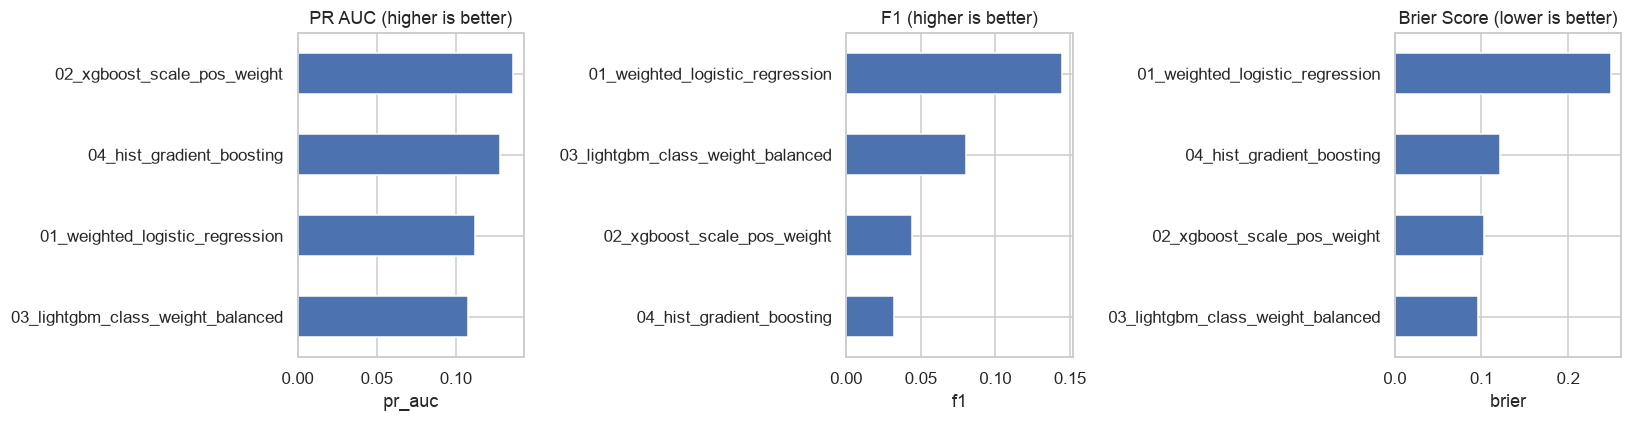

In [10]:
plot_results = results.set_index("model")[["pr_auc", "f1", "brier"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, metric, title in zip(
    axes,
    ["pr_auc", "f1", "brier"],
    ["PR AUC (higher is better)", "F1 (higher is better)", "Brier Score (lower is better)"],
):
    plot_results[metric].sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.tight_layout()

## Calibration Curves

Use these if the predicted probability itself matters, for example if operations will rank orders by expected risk or if thresholds will be tied to intervention costs. Class weighting often improves recall but can make probabilities overconfident, so the curve and Brier score should be checked before treating scores as calibrated probabilities.

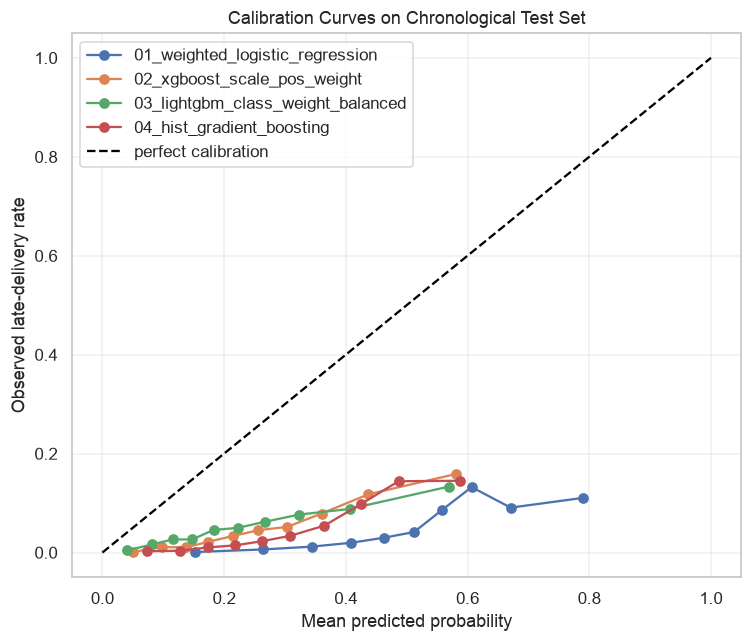

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in test_probabilities.items():
    frac_pos, mean_pred = calibration_curve(
        test[TARGET_COLUMN],
        proba,
        n_bins=10,
        strategy="quantile",
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="perfect calibration")
ax.set_title("Calibration Curves on Chronological Test Set")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed late-delivery rate")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()

## Logistic Regression Interpretation

The coefficient table below is only for the weighted logistic regression baseline. Numeric coefficients are on standardized features; categorical coefficients are one-hot encoded levels. Positive coefficients increase late-delivery odds, while negative coefficients decrease them.

In [12]:
logit_name = "01_weighted_logistic_regression"
if logit_name in fitted_models:
    logit_model = fitted_models[logit_name]
    feature_names = logit_model.named_steps["prep"].get_feature_names_out()
    coefficients = logit_model.named_steps["clf"].coef_[0]

    coef_table = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
            "abs_coefficient": np.abs(coefficients),
        }
    ).sort_values("abs_coefficient", ascending=False)

    display(coef_table.head(20))

,feature,coefficient,odds_ratio,abs_coefficient
39,cat__customer_state_RO,-1.139,0.320,1.139
20,cat__customer_state_AL,1.053,2.865,1.053
19,cat__customer_state_AC,-0.968,0.380,0.968
55,cat__seller_state_PE,-0.794,0.452,0.794
47,cat__seller_state_CE,0.769,2.158,0.769
37,cat__customer_state_RJ,0.737,2.089,0.737
0,num__estimated_delivery_days,-0.736,0.479,0.736
54,cat__seller_state_MT,-0.729,0.482,0.729
53,cat__seller_state_MS,-0.617,0.539,0.617
61,cat__seller_state_SP,0.586,1.796,0.586


## Reading the Benchmark

- For pure late-order **ranking**, prefer the model with the strongest **test PR AUC**. In the displayed benchmark run, that is XGBoost.
- For an alerting workflow that needs a hard class decision, read **F1** together with the validation-selected threshold shown in `results`; changing the threshold changes F1.
- **Why production now ships XGBoost.** The latest comparison shows `02_xgboost_scale_pos_weight` slightly ahead of `04_hist_gradient_boosting` on validation F1, PR AUC, thresholded F1, and Brier score. HistGradientBoosting is still useful as a simpler pure scikit-learn fallback, but dependency simplicity is not the deciding constraint for this project.
- If the model output will be consumed as a probability, inspect **Brier score** and the calibration curve before trusting raw weighted-model probabilities.
- If calibration is poor but ranking is good, add a calibration step such as `CalibratedClassifierCV` on a later validation period before choosing an operating threshold.


## Production API (promoted to `src/`)

The evaluation helpers below are prototyped here and then promoted to
`src/evaluate.py`, so the CLI (`python -m src.main`) and the tests share the
same logic:

- `time_based_split`, `best_f1_threshold`, `evaluate_classifier` -> `src/evaluate.py`

Unlike the exploratory three-way split above, the production smoke test starts
with a simpler chronological **train/test** split. `train_model_artifact` then
uses only the production-training period to select an F1-oriented operating
threshold on an internal chronological validation slice, refits the estimator on
the full production-training period, and carries that threshold in the returned
artifact.

The held-out test metrics below pass `artifact.threshold` explicitly. This keeps
threshold selection out of the test labels; calling `evaluate_classifier` with
`threshold=None` on the test period would optimize F1 on the test set itself.

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score


def time_based_split(
    dataset: pd.DataFrame,
    test_frac: float = 0.2,
    time_column: str = TIME_COLUMN,
) -> tuple[pd.DataFrame, pd.DataFrame]:  # promoted to src/evaluate.py::time_based_split
    """Split chronologically into (train, test), holding out the most-recent rows."""
    if not 0.0 < test_frac < 1.0:
        raise ValueError("test_frac must be between 0 and 1 (exclusive).")

    ordered = dataset.sort_values(time_column).reset_index(drop=True)
    test_start = int(len(ordered) * (1 - test_frac))
    return ordered.iloc[:test_start].copy(), ordered.iloc[test_start:].copy()


# best_f1_threshold is prototyped once in the "Fit and Evaluate" section above (and is
# likewise promoted to src/evaluate.py::best_f1_threshold); reused here, not redefined.
def evaluate_classifier(
    y_true: pd.Series,
    y_proba: np.ndarray,
    threshold: float | None = None,
) -> dict[str, float]:  # promoted to src/evaluate.py::evaluate_classifier
    """Score probabilistic predictions with ranking, calibration and F1 metrics."""
    if threshold is None:
        threshold, _ = best_f1_threshold(y_true, y_proba)  # src/evaluate.py::best_f1_threshold

    y_pred = (y_proba >= threshold).astype(int)
    return {
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "brier": float(brier_score_loss(y_true, y_proba)),
        "f1": float(f1_score(y_true, y_pred)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }

In [ ]:
# src/ is the source of truth: import the promoted versions and smoke-test them.
from src.evaluate import evaluate_classifier, time_based_split
from src.model import score_customer_orders, train_model_artifact

prod_train, prod_test = time_based_split(df, test_frac=0.2)  # src/evaluate.py::time_based_split
artifact = train_model_artifact(prod_train)  # src/model.py::train_model_artifact

test_proba = artifact.estimator.predict_proba(prod_test[FEATURE_COLUMNS])[:, 1]
print(
    f"Held-out test metrics for {artifact.model_name} "
    f"using artifact threshold={artifact.threshold:.3f}:"
)
display(
    pd.Series(
        evaluate_classifier(
            prod_test[TARGET_COLUMN],
            test_proba,
            threshold=artifact.threshold,
        )
    )
)  # src/evaluate.py::evaluate_classifier

sample_customer = df["customer_id"].iloc[0]
print(f"\nScoring sample customer_id={sample_customer}")
score_customer_orders(artifact, df, customer_id=sample_customer, top_k=5)  # src/model.py::score_customer_orders